# Libraries


In [1]:
import os
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, List, Tuple

from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Parameters

In [2]:
# --- CONFIGURATION ---
BASE_MODEL_ID = "Qwen/Qwen3.5-4B"
ADAPTER_PATH = "./qwen-mathbridge-qlora/final" 
DATASET_ID = "Kyudan/MathBridge"
DATASET_SPLIT = "train"
SHUFFLE_SEED = 42
sample_sizes = [100,500,1000,2000]

# Functions to plot the different statistics

## Plot the distribution

In [3]:
def plot_latex_complexity_distribution(df, figsize=(18, 12)):
    """
    Plot distributions of all LaTeX complexity columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with latex_* columns
    figsize : tuple
        Figure size (width, height)
    """
    
    # Get all latex columns
    latex_cols = [col for col in df.columns if col.startswith('latex_')]
    
    # Create subplots
    n_cols = 4
    n_rows = (len(latex_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to 1D array for easier indexing
    
    # Set style
    sns.set_style("whitegrid")
    
    for idx, col in enumerate(latex_cols):
        ax = axes[idx]
        
        # Plot histogram with KDE
        data = df[col].dropna()
        
        ax.hist(data, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f"Mean: {data.mean():.2f}\nMedian: {data.median():.2f}\nMax: {data.max():.2f}"
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Hide extra subplots
    for idx in range(len(latex_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('latex_complexity_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Plot saved as 'latex_complexity_distribution.png'")

## Function to plot the correlation matrix of the complexity columns

Cette fonction nous a permis de nous rendre compte que des colonnes qu'on avait aujouté au début n'avaient pas beaucoup d'interêt

In [4]:
def plot_latex_complexity_correlation(df, figsize=(14, 12)):
    """
    Plot correlation matrix of all LaTeX complexity columns.
    """
    
    latex_cols = [col for col in df.columns if col.startswith('latex_')]
    
    # Calculate correlation
    corr_matrix = df[latex_cols].corr()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(corr_matrix, 
                annot=True,                    # Show correlation values
                fmt='.2f',                     # 2 decimal places
                cmap='RdBu_r',                 # Red-Blue diverging colormap
                center=0,                      # Center at 0
                square=True,                   # Square cells
                linewidths=0.5,                # Cell borders
                cbar_kws={'label': 'Correlation Coefficient'},
                xticklabels=[c.replace('latex_', '') for c in latex_cols],
                yticklabels=[c.replace('latex_', '') for c in latex_cols],
                ax=ax,
                vmin=-1, vmax=1)               # Scale from -1 to 1
    
    ax.set_title('LaTeX Complexity Metrics - Correlation Heatmap', 
                 fontsize=16, fontweight='bold', pad=20)
    
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig('latex_complexity_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Correlation heatmap saved as 'latex_complexity_correlation_heatmap.png'")

# Preprocessing

## Charge de la base de données de HF

In [5]:
def load_and_process_dataset(
    download: bool, 
    dataset_id=DATASET_ID, 
    split=DATASET_SPLIT, 
    shuffle_seed: int = 42, 
    output_folder: str = "samples"
) -> pd.DataFrame:
    """
    Load, shuffle, and sample a dataset.
    
    If the CSV file already exists in output_folder, it will be read from disk.
    Otherwise, it will be downloaded from Hugging Face Hub.
    
    Args:
        download (bool): If True, saves the dataset to CSV in output_folder. If False, only loads to memory.
        dataset_id (str): The dataset identifier on Hugging Face Hub
        split (str): The dataset split to load
        shuffle_seed (int): Random seed for shuffling
        num_samples (int): Number of samples to take
        output_folder (str): Folder where to save/read the CSV
    
    Returns:
        pd.DataFrame: The processed dataset as a pandas DataFrame
    """
    
    output_path = os.path.join(output_folder, "dataset_sample.csv")
    
    # Check if CSV already exists locally
    if os.path.exists(output_path):
        print(f"📂 Found existing dataset at: {output_path}")
        df = pd.read_csv(output_path)
        print(f"✓ Dataset loaded from disk ({len(df)} rows)")
        return df
    
    # If file doesn't exist, download from Hugging Face
    print(f"📥 Downloading dataset from Hugging Face: {dataset_id} (split: {split})...")
    dataset = load_dataset(dataset_id, split=split)
    dataset = dataset.shuffle(seed=shuffle_seed)
    df = dataset.to_pandas()
    
    
    if download:
        # Create output folder if it doesn't exist
        os.makedirs(output_folder, exist_ok=True)
        
        # Save to CSV
        df.to_csv(output_path, index=False)
        print(f"✓ Dataset downloaded and saved to: {output_path}")
    else:
        print(f"✓ Dataset loaded in memory ({len(df)} rows)")
    
    return df


# Usage
df = load_and_process_dataset(download=True)

📂 Found existing dataset at: samples/dataset_sample.csv
✓ Dataset loaded from disk (23195831 rows)


## Ajout de colonnes de statistiques au set

In [6]:
def simplified_add_latex_complexity_columns(df, latex_column='equation'):
    """
    Add complexity measurement columns for LaTeX expressions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing LaTeX expressions
    latex_column : str
        Name of the column containing LaTeX expressions
    
    Returns:
    --------
    df : pandas.DataFrame
        DataFrame with 9 new complexity columns added
    """
    
    def extract_latex_expr(text):
        """Extract LaTeX expressions from text"""
        if pd.isna(text):
            return []
        expressions = re.findall(r'\$[^$]+\$', str(text))
        return expressions
    
    def clean_expr(expr):
        """Remove $ delimiters"""
        return re.sub(r'^\$+|\$+$', '', expr)
    
    def count_symbols(expr):
        """Count various symbol types"""
        commands = len(re.findall(r'\\[a-zA-Z]+', expr))
        operators = len(re.findall(r'[+\-*/=<>]', expr))
        braces = expr.count('{') + expr.count('}')
        subscripts = expr.count('_')
        superscripts = expr.count('^')
        
        return {
            'commands': commands,
            'operators': operators,
            'braces': braces,
            'subscripts': subscripts,
            'superscripts': superscripts
        }
    
    def calc_nesting_depth(expr):
        """Calculate maximum nesting depth"""
        max_depth = 0
        current_depth = 0
        
        for char in expr:
            if char == '{':
                current_depth += 1
                max_depth = max(max_depth, current_depth)
            elif char == '}':
                current_depth -= 1
        
        return max_depth
    
    def calc_complexity_score(expr):
        """Calculate comprehensive complexity score"""
        length = len(expr)
        depth = calc_nesting_depth(expr)
        
        symbols = count_symbols(expr)
        unique_commands = len(set(re.findall(r'\\[a-zA-Z]+', expr)))
        
        score = (
            length * 0.1 +
            depth * 2 +
            unique_commands * 1.5 +
            symbols['operators'] * 0.5 +
            (symbols['subscripts'] + symbols['superscripts']) * 1
        )
        
        return score
    
    def process_row(text):
        """Process a single row and return 9 metrics"""
        if pd.isna(text):
            return {
                'num_expressions': 0,
                'total_length': 0,
                'total_commands': 0,
                'total_nesting_depth': 0,
                'total_subscripts': 0,
                'total_superscripts': 0,
                'total_braces': 0,
                'avg_complexity_score': 0,
                'total_operators': 0,
            }
        
        expressions = extract_latex_expr(text)
        
        if not expressions:
            return {
                'num_expressions': 0,
                'total_length': 0,
                'total_commands': 0,
                'total_nesting_depth': 0,
                'total_subscripts': 0,
                'total_superscripts': 0,
                'total_braces': 0,
                'avg_complexity_score': 0,
                'total_operators': 0,
            }
        
        num_expr = len(expressions)
        total_length = 0
        all_commands = 0
        all_operators = 0
        total_nesting_depth = 0
        all_subscripts = 0
        all_superscripts = 0
        all_braces = 0
        complexity_scores = []
        
        for expr in expressions:
            clean = clean_expr(expr)
            
            # Length
            total_length += len(clean)
            
            # Symbol counts
            symbols = count_symbols(clean)
            all_commands += symbols['commands']
            all_operators += symbols['operators']
            all_subscripts += symbols['subscripts']
            all_superscripts += symbols['superscripts']
            all_braces += symbols['braces']
            
            # Nesting depth
            depth = calc_nesting_depth(clean)
            total_nesting_depth += depth
            
            # Complexity score
            score = calc_complexity_score(clean)
            complexity_scores.append(score)
        
        return {
            'num_expressions': num_expr,
            'total_length': total_length,
            'total_commands': all_commands,
            'total_nesting_depth': total_nesting_depth,
            'total_subscripts': all_subscripts,
            'total_superscripts': all_superscripts,
            'total_braces': all_braces,
            'avg_complexity_score': sum(complexity_scores) / num_expr if complexity_scores else 0,
            'total_operators': all_operators,
        }
    
    # Apply to all rows
    print("Processing LaTeX expressions...")
    metrics = df[latex_column].apply(process_row)
    metrics_df = pd.DataFrame(list(metrics))
    
    # Add all columns to original dataframe
    for col in metrics_df.columns:
        df[f'latex_{col}'] = metrics_df[col]
    
    print(f"✓ Added {len(metrics_df.columns)} new columns")
    print("\nNew columns (9 total):")
    for col in sorted(metrics_df.columns):
        print(f"  - latex_{col}")
    
    return df

# Usage
df = simplified_add_latex_complexity_columns(df, latex_column='equation')

Processing LaTeX expressions...


✓ Added 9 new columns

New columns (9 total):
  - latex_avg_complexity_score
  - latex_num_expressions
  - latex_total_braces
  - latex_total_commands
  - latex_total_length
  - latex_total_nesting_depth
  - latex_total_operators
  - latex_total_subscripts
  - latex_total_superscripts


## Statistiques descriptives sur la base de données initiale

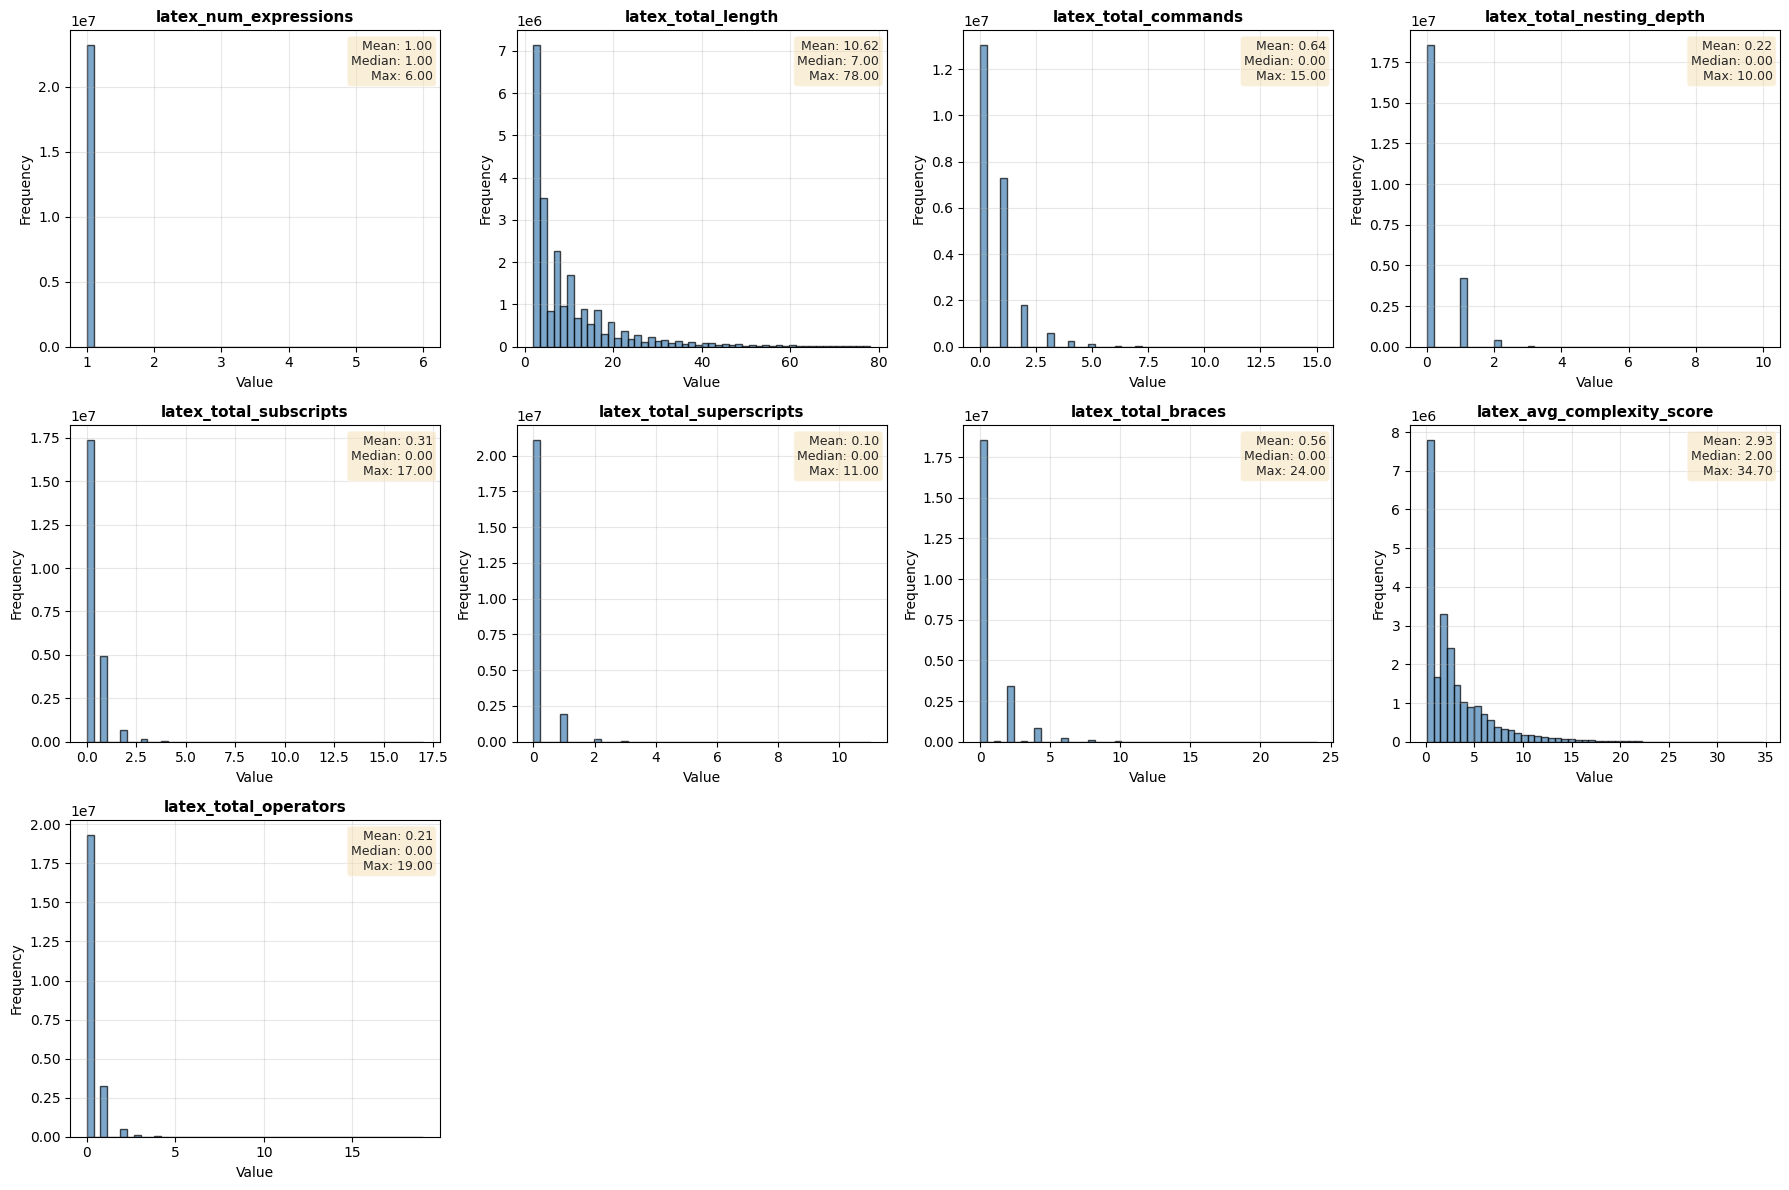

✓ Plot saved as 'latex_complexity_distribution.png'


In [7]:
# Usage
plot_latex_complexity_distribution(df)

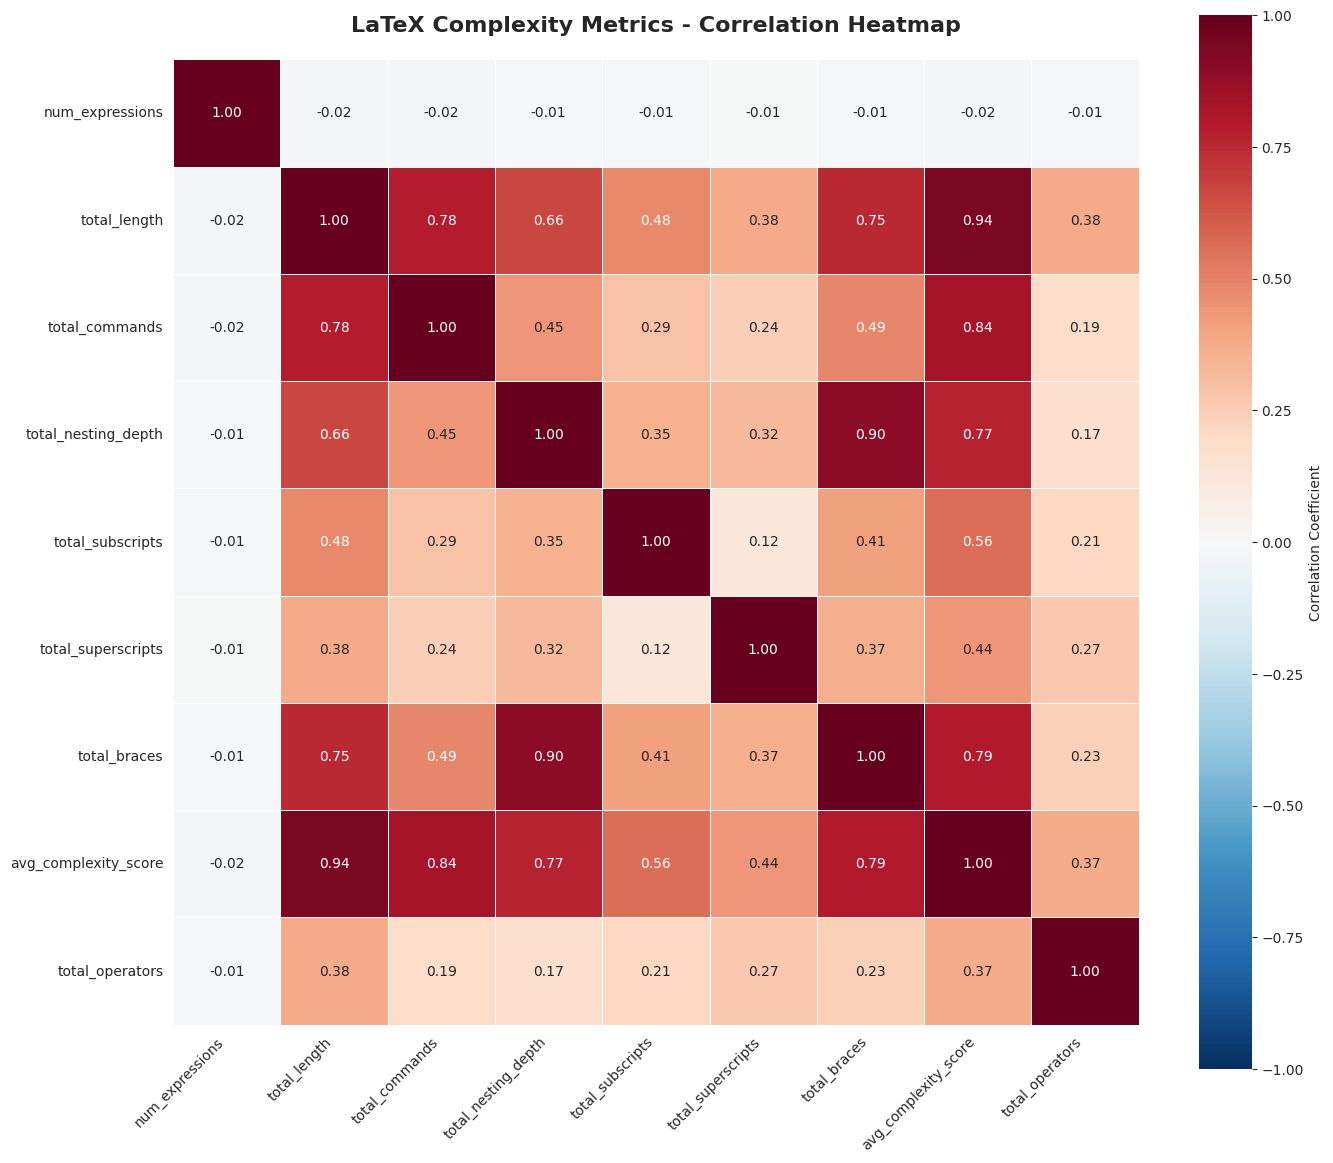

✓ Correlation heatmap saved as 'latex_complexity_correlation_heatmap.png'


In [8]:
plot_latex_complexity_correlation(df)

## PCA des colonnes de statistiques pour réduire la dimension de la compléxité

Original shape: (23195831, 9)
Columns: ['latex_num_expressions', 'latex_total_length', 'latex_total_commands', 'latex_total_nesting_depth', 'latex_total_subscripts', 'latex_total_superscripts', 'latex_total_braces', 'latex_avg_complexity_score', 'latex_total_operators']

PCA ANALYSIS RESULTS

Explained Variance Ratio:
  PC1: 0.5073 (50.73%)
  PC2: 0.1111 (11.11%)

Cumulative Explained Variance: 0.6184 (61.84%)

Principal Components (Loadings):
                           PC1       PC2
num_expressions      -0.011199  0.982848
total_length          0.436844  0.000265
total_commands        0.355315  0.012363
total_nesting_depth   0.383169  0.066553
total_subscripts      0.264055  0.002472
total_superscripts    0.227777 -0.070378
total_braces          0.406310  0.054713
avg_complexity_score  0.461023  0.004808
total_operators       0.191669 -0.146461



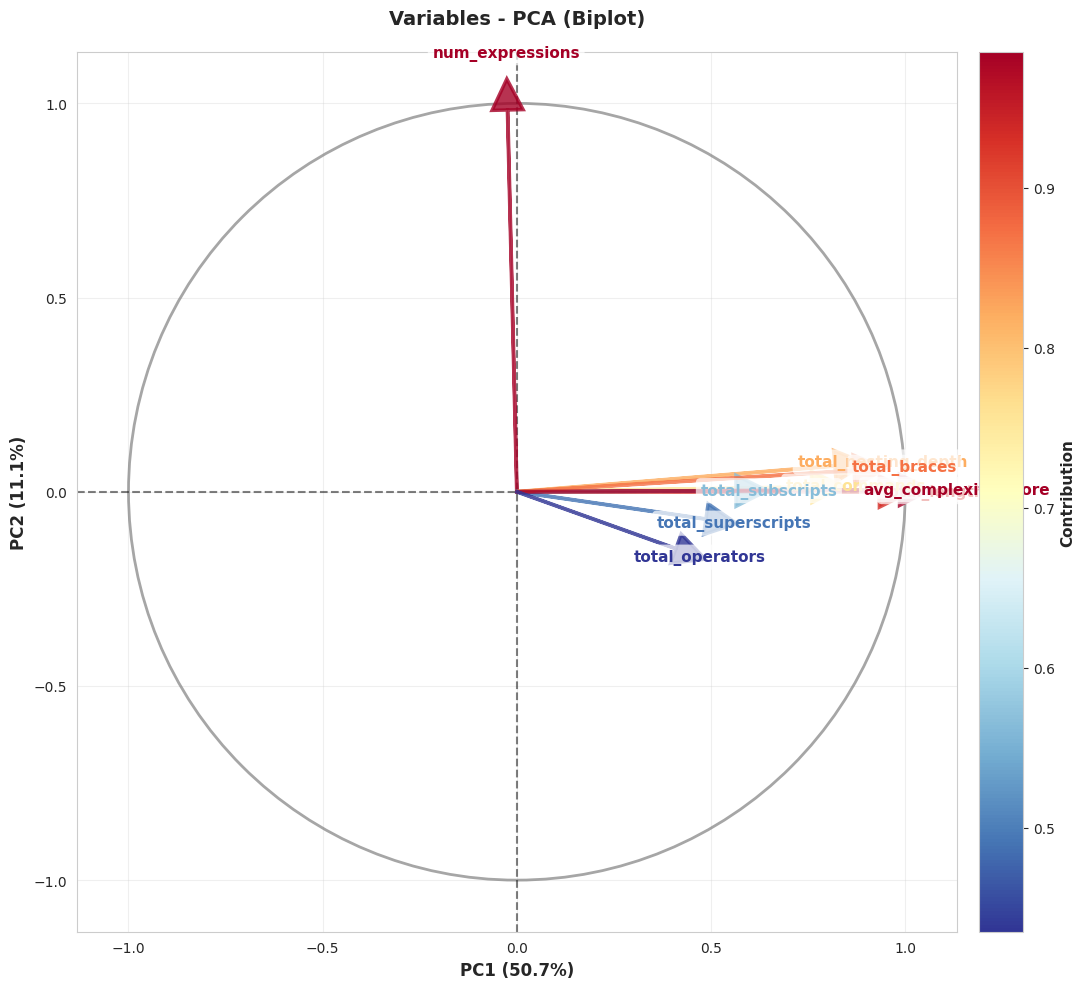

✓ Saved 'pca_biplot.png'

FEATURE CONTRIBUTIONS TO PCA COMPONENTS

PC1 (Explains 50.7% of variance):
  1. → avg_complexity_score      |   0.4610 | ███████████████████████
  2. → total_length              |   0.4368 | █████████████████████
  3. → total_braces              |   0.4063 | ████████████████████
  4. → total_nesting_depth       |   0.3832 | ███████████████████
  5. → total_commands            |   0.3553 | █████████████████
  6. → total_subscripts          |   0.2641 | █████████████
  7. → total_superscripts        |   0.2278 | ███████████
  8. → total_operators           |   0.1917 | █████████
  9. ← num_expressions           |  -0.0112 | 

PC2 (Explains 11.1% of variance):
  1. → num_expressions           |   0.9828 | █████████████████████████████████████████████████
  2. ← total_operators           |  -0.1465 | ███████
  3. ← total_superscripts        |  -0.0704 | ███
  4. → total_nesting_depth       |   0.0666 | ███
  5. → total_braces              |   0.0547 | ██
  6. → to

In [9]:
def plot_pca_contributions_biplot(pca, feature_names, df=None, n_components=2):
    """
    Create a biplot showing how each LaTeX feature contributes to PCA components.
    Arrows radiate from origin showing loading direction and magnitude.
    
    Parameters:
    - pca: Fitted PCA object from sklearn
    - feature_names: List of column names (including 'latex_' prefix)
    - df: Optional dataframe with pca_1 and pca_2 columns for background points
    - n_components: Number of PCA components to visualize (default: 2)
    """
    
    # Clean feature names for display
    clean_names = [col.replace('latex_', '') for col in feature_names]
    
    # Get the loadings (components)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_[:n_components])
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Set up the plot limits based on loadings
    max_loading = np.abs(loadings).max() * 1.15
    
    # Draw circle (correlation circle)
    circle = plt.Circle((0, 0), 1, fill=False, edgecolor='gray', linestyle='-', linewidth=2, alpha=0.7)
    ax.add_patch(circle)
    
    # Draw axes
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    
    # Get contributions for color mapping
    contributions = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    norm = plt.Normalize(vmin=contributions.min(), vmax=contributions.max())
    cmap = plt.cm.RdYlBu_r
    
    # Plot arrows for each variable
    for i, (x, y) in enumerate(loadings[:, :2]):
        color = cmap(norm(contributions[i]))
        
        ax.arrow(0, 0, x, y, head_width=0.08, head_length=0.08, 
                fc=color, ec=color, linewidth=2.5, alpha=0.8, zorder=3)
        
        # Label positioning (slightly beyond the arrow tip)
        offset = 1.15
        ax.text(x * offset, y * offset, clean_names[i], 
               fontsize=11, weight='bold', ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7),
               color=color, zorder=4)
    
    # Add colorbar for contributions
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Contribution', fontsize=11, weight='bold')
    
    # Labels and title
    pc1_var = pca.explained_variance_ratio_[0] * 100
    pc2_var = pca.explained_variance_ratio_[1] * 100
    
    ax.set_xlabel(f'PC1 ({pc1_var:.1f}%)', fontsize=12, weight='bold')
    ax.set_ylabel(f'PC2 ({pc2_var:.1f}%)', fontsize=12, weight='bold')
    ax.set_title('Variables - PCA (Biplot)', fontsize=14, weight='bold', pad=20)
    
    # Set limits
    ax.set_xlim(-max_loading, max_loading)
    ax.set_ylim(-max_loading, max_loading)
    
    # Grid
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig('pca_biplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved 'pca_biplot.png'")
    
    # Print contribution summary
    print("\n" + "="*100)
    print("FEATURE CONTRIBUTIONS TO PCA COMPONENTS")
    print("="*100)
    
    for comp_idx in range(n_components):
        print(f"\nPC{comp_idx+1} (Explains {pca.explained_variance_ratio_[comp_idx]*100:.1f}% of variance):")
        loadings_comp = pca.components_[comp_idx]
        sorted_idx = np.argsort(np.abs(loadings_comp))[::-1]
        
        for rank, idx in enumerate(sorted_idx, 1):
            loading = loadings_comp[idx]
            bar_length = int(abs(loading) * 50)
            direction = "→" if loading > 0 else "←"
            print(f"  {rank}. {direction} {clean_names[idx]:25s} | {loading:8.4f} | {'█' * bar_length}")
    
    print("\n" + "="*100)


# Updated main function
def apply_pca_to_latex_metrics(df, n_components=2, plot=True):
    """
    Apply PCA to reduce LaTeX complexity columns to principal components.
    Creates a biplot showing feature contributions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Original dataframe with latex_* columns
    n_components : int
        Number of components (default: 2)
    plot : bool
        Whether to plot the biplot
    
    Returns:
    --------
    df : pandas.DataFrame
        DataFrame with PCA1 and PCA2 columns added
    pca : PCA object
        Fitted PCA object
    scaler : StandardScaler object
        Fitted scaler for future transformations
    """
    
    # Get LaTeX columns
    latex_cols = [col for col in df.columns if col.startswith('latex_')]
    X = df[latex_cols].copy()
    
    # Handle missing values
    X = X.fillna(X.mean())
    
    print(f"Original shape: {X.shape}")
    print(f"Columns: {latex_cols}\n")
    
    # Standardize the features (CRITICAL for PCA)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    # Add PCA columns to dataframe
    df['pca_1'] = X_pca[:, 0]
    df['pca_2'] = X_pca[:, 1]
    
    # Print information
    print("="*100)
    print("PCA ANALYSIS RESULTS")
    print("="*100)
    print(f"\nExplained Variance Ratio:")
    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
    
    print(f"\nCumulative Explained Variance: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")
    
    print(f"\nPrincipal Components (Loadings):")
    loadings_df = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=[col.replace('latex_', '') for col in latex_cols]
    )
    print(loadings_df.to_string())
    
    print("\n" + "="*100)
    
    # Plot biplot
    if plot:
        plot_pca_contributions_biplot(pca, latex_cols, df=df, n_components=n_components)
    
    return df, pca, scaler


# Usage
df, pca, scaler = apply_pca_to_latex_metrics(df, n_components=2, plot=True)

# Check new columns
print("\nNew PCA columns added:")
print(df[['pca_1', 'pca_2']].describe())
print("\nFirst 5 rows:")
print(df[['equation', 'pca_1', 'pca_2']].head())

## Création des différentes bases de données

In [10]:
def create_stratified_samples_pca(df, sample_sizes, test_size=2000, pca1_bins=4, pca2_bins=8, random_state=42):
    """
    Create stratified train/test split and stratified training samples using PCA components.
    
    Parameters:
    - df: Input dataframe
    - sample_sizes: List of training sample sizes to create
    - test_size: Size of the test set (fixed for all experiments)
    - pca1_bins: Number of bins for PCA1 stratification (default: 4)
    - pca2_bins: Number of bins for PCA2 stratification (default: 4)
    - random_state: Random seed for reproducibility
    """
    
    # Ensure we have enough data
    total_needed = max(sample_sizes) + test_size
    if len(df) < total_needed:
        print(f"⚠️  Warning: Total data ({len(df)}) < max_sample_size ({max(sample_sizes)}) + test_size ({test_size})")
    
    # First: Create TEST SET (stratified by PCA)
    df_temp = df.copy()
    
    # Create stratification for test split
    pca1_cat = pd.cut(
        df_temp['pca_1'], 
        bins=pca1_bins, 
        labels=[f'PCA1_Class_{i+1}' for i in range(pca1_bins)],
        duplicates='drop'
    ).astype(str)
    
    pca2_cat = pd.cut(
        df_temp['pca_2'], 
        bins=pca2_bins, 
        labels=[f'PCA2_Class_{i+1}' for i in range(pca2_bins)],
        duplicates='drop'
    ).astype(str)
    
    df_temp['_pca_strata'] = pca1_cat + '_' + pca2_cat
    
    # Stratified test split
    test_df = df_temp.groupby('_pca_strata', group_keys=False).apply(
        lambda x: x.sample(n=max(1, int(len(x) * test_size / len(df_temp))), random_state=random_state)
    ).reset_index(drop=True)
    
    # Adjust test set to exact size
    if len(test_df) > test_size:
        test_df = test_df.sample(n=test_size, random_state=random_state).reset_index(drop=True)
    elif len(test_df) < test_size:
        remaining = test_size - len(test_df)
        additional = df_temp.drop(test_df.index).sample(n=min(remaining, len(df_temp) - len(test_df)), random_state=random_state)
        test_df = pd.concat([test_df, additional], ignore_index=True).reset_index(drop=True)
    
    test_df = test_df.drop('_pca_strata', axis=1)
    print(f"\n✓ Created TEST SET with {len(test_df)} samples")
    print(f"  PCA ranges: PCA1 [{test_df['pca_1'].min():.2f}, {test_df['pca_1'].max():.2f}] | PCA2 [{test_df['pca_2'].min():.2f}, {test_df['pca_2'].max():.2f}]")
    
    # Second: Create TRAINING SAMPLES from remaining data
    df_train = df_temp.drop(test_df.index).reset_index(drop=True)
    
    samples = {'test': test_df}
    
    print(f"\nCreated {len(df_train['_pca_strata'].unique())} stratification groups for training")
    
    for size in sample_sizes:
        if size > len(df_train):
            print(f"⚠️  Sample size {size} > training dataframe size ({len(df_train)}). Using full training data.")
            samples[f'train_{size}'] = df_train.drop('_pca_strata', axis=1).copy()
            continue
        
        # Stratified sample
        sampled_df = df_train.groupby('_pca_strata', group_keys=False).apply(
            lambda x: x.sample(n=max(1, int(len(x) * size / len(df_train))), random_state=random_state)
        ).reset_index(drop=True)
        
        # Adjust to exact size
        if len(sampled_df) > size:
            sampled_df = sampled_df.sample(n=size, random_state=random_state)
        elif len(sampled_df) < size:
            missing = size - len(sampled_df)
            additional = df_train.drop(sampled_df.index).sample(n=missing, random_state=random_state)
            sampled_df = pd.concat([sampled_df, additional], ignore_index=True)
        
        sampled_df = sampled_df.drop('_pca_strata', axis=1)
        samples[f'train_{size}'] = sampled_df.reset_index(drop=True)
        
        print(f"✓ Created train_{size} with {len(sampled_df)} samples")
    
    return samples


# Usage
# Load your dataset
# Create stratified samples with fixed test set
sample_dfs = create_stratified_samples_pca(
    df,
    sample_sizes=[100, 500, 1000, 2000],
    test_size=2000,
    pca1_bins=8,
    pca2_bins=4,
    random_state=42
)

# Access your data
test_df = sample_dfs['test']
train_100 = sample_dfs['train_100']
train_500 = sample_dfs['train_500']
train_1000 = sample_dfs['train_1000']
train_2000 = sample_dfs['train_2000']

/tmp/ipykernel_196983/2449613252.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = df_temp.groupby('_pca_strata', group_keys=False).apply(



✓ Created TEST SET with 2000 samples
  PCA ranges: PCA1 [-1.99, 19.69] | PCA2 [-1.61, 169.40]

Created 16 stratification groups for training


/tmp/ipykernel_196983/2449613252.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_train.groupby('_pca_strata', group_keys=False).apply(


✓ Created train_100 with 100 samples


/tmp/ipykernel_196983/2449613252.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_train.groupby('_pca_strata', group_keys=False).apply(


✓ Created train_500 with 500 samples


/tmp/ipykernel_196983/2449613252.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_train.groupby('_pca_strata', group_keys=False).apply(


✓ Created train_1000 with 1000 samples


/tmp/ipykernel_196983/2449613252.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_train.groupby('_pca_strata', group_keys=False).apply(


✓ Created train_2000 with 2000 samples


### Téléchargement des bases de données

In [11]:
# Download all dataframes to CSV
output_folder = "samples"
os.makedirs(output_folder, exist_ok=True)

# Dictionary of dataframes to save
dfs_to_save = {
    'test': test_df,
    'train_100': train_100,
    'train_500': train_500,
    'train_1000': train_1000,
    'train_2000': train_2000
}

print(f"\n{'='*70}")
print("SAVING DATASETS TO CSV")
print(f"{'='*70}\n")

for name, d in dfs_to_save.items():
    filepath = os.path.join(output_folder, f"{name}.csv")
    d.to_csv(filepath, index=False)
    print(f"✓ Saved {name:15s} ({len(d):5d} rows) → {filepath}")

print(f"\n{'='*70}\n")


SAVING DATASETS TO CSV

✓ Saved test            ( 2000 rows) → samples/test.csv
✓ Saved train_100       (  100 rows) → samples/train_100.csv
✓ Saved train_500       (  500 rows) → samples/train_500.csv
✓ Saved train_1000      ( 1000 rows) → samples/train_1000.csv
✓ Saved train_2000      ( 2000 rows) → samples/train_2000.csv




### Comparaison de des différentes métriques de compléxité entre les différentes bdd


COMPARING DISTRIBUTIONS: Original (n=23195831) vs Train_100 (n=100)



1. avg_complexity_score          
   Original: μ=  2.9282, σ=  3.3912, min=  0.1000, max= 34.7000
   Train_100: μ=  3.3399, σ=  5.0016, min=  0.1000, max= 29.6000
   Δμ = 0.4117

2. total_length                  
   Original: μ= 10.6208, σ= 10.9751, min=  2.0000, max= 78.0000
   Train_100: μ= 13.3100, σ= 16.0691, min=  2.0000, max= 76.0000
   Δμ = 2.6892

3. total_braces                  
   Original: μ=  0.5551, σ=  1.3065, min=  0.0000, max= 24.0000
   Train_100: μ=  0.8200, σ=  2.0714, min=  0.0000, max= 12.0000
   Δμ = 0.2649

4. total_nesting_depth           
   Original: μ=  0.2214, σ=  0.4658, min=  0.0000, max= 10.0000
   Train_100: μ=  0.3000, σ=  0.7177, min=  0.0000, max=  5.0000
   Δμ = 0.0786

5. total_commands                
   Original: μ=  0.6422, σ=  0.9567, min=  0.0000, max= 15.0000
   Train_100: μ=  0.7500, σ=  1.1044, min=  0.0000, max=  5.0000
   Δμ = 0.1078

6. total_subscripts              
   Original: μ=  0.3077, σ=  0.6073, min=  0.0000, max= 17.0000
   Trai

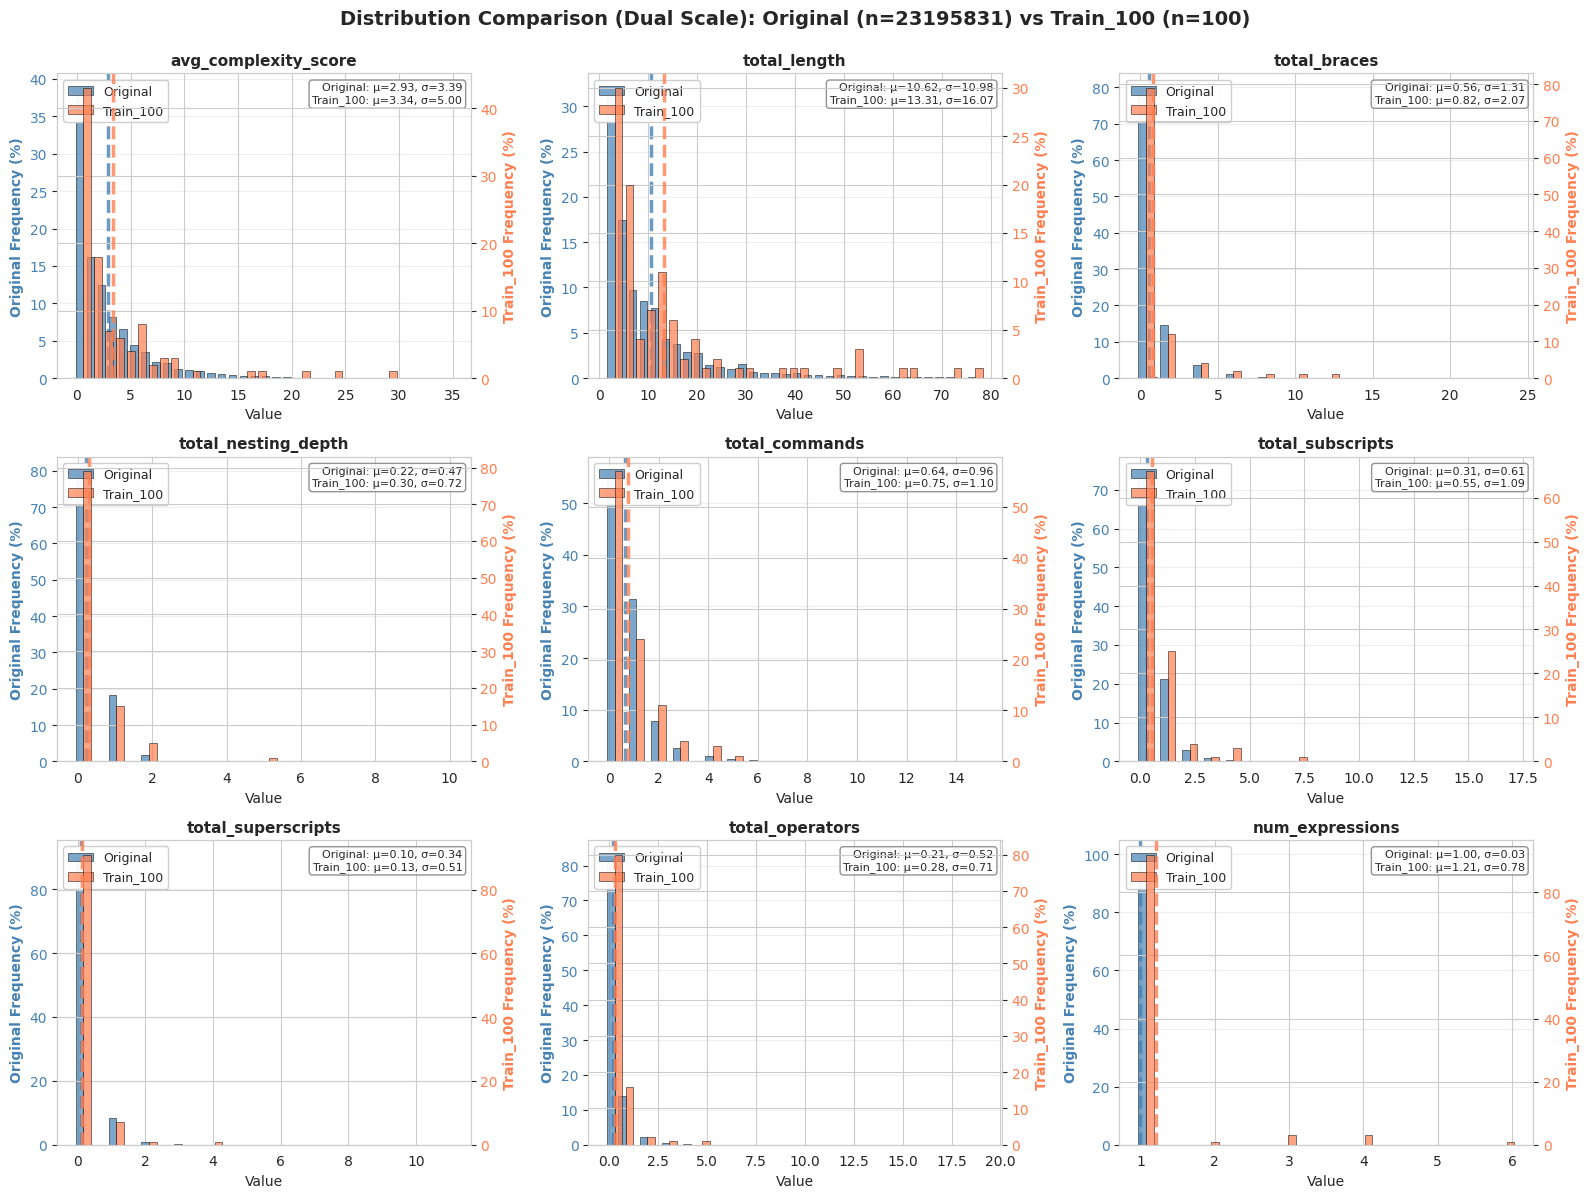


✓ Saved 'distribution_dual_scale_original_vs_train_100.png'


COMPARING DISTRIBUTIONS: Original (n=23195831) vs Train_500 (n=500)

1. avg_complexity_score          
   Original: μ=  2.9282, σ=  3.3912, min=  0.1000, max= 34.7000
   Train_500: μ=  2.9402, σ=  3.6929, min=  0.1000, max= 29.6000
   Δμ = 0.0120

2. total_length                  
   Original: μ= 10.6208, σ= 10.9751, min=  2.0000, max= 78.0000
   Train_500: μ= 11.0540, σ= 12.1052, min=  2.0000, max= 76.0000
   Δμ = 0.4332

3. total_braces                  
   Original: μ=  0.5551, σ=  1.3065, min=  0.0000, max= 24.0000
   Train_500: μ=  0.5840, σ=  1.4530, min=  0.0000, max= 12.0000
   Δμ = 0.0289

4. total_nesting_depth           
   Original: μ=  0.2214, σ=  0.4658, min=  0.0000, max= 10.0000
   Train_500: μ=  0.2300, σ=  0.5231, min=  0.0000, max=  5.0000
   Δμ = 0.0086

5. total_commands                
   Original: μ=  0.6422, σ=  0.9567, min=  0.0000, max= 15.0000
   Train_500: μ=  0.6200, σ=  0.9040, min=  0.0000, ma

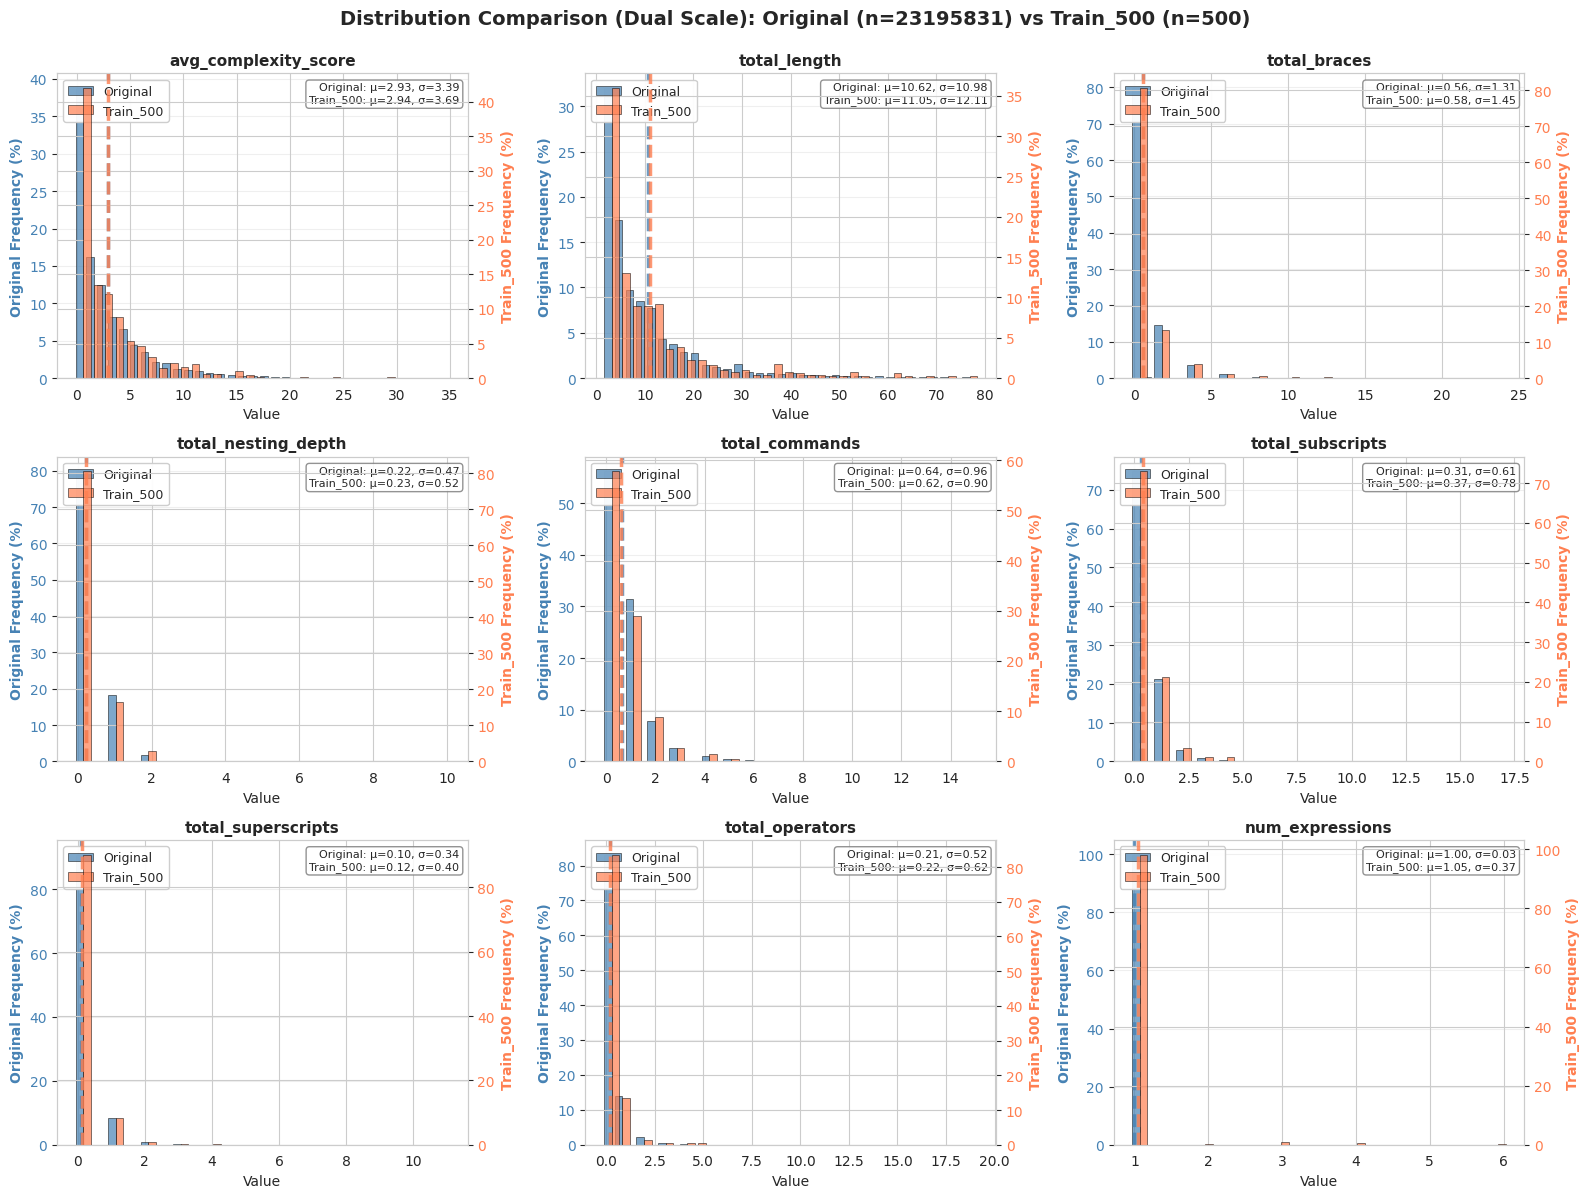


✓ Saved 'distribution_dual_scale_original_vs_train_500.png'


COMPARING DISTRIBUTIONS: Original (n=23195831) vs Train_1000 (n=1000)

1. avg_complexity_score          
   Original: μ=  2.9282, σ=  3.3912, min=  0.1000, max= 34.7000
   Train_1000: μ=  2.9069, σ=  3.4788, min=  0.1000, max= 29.6000
   Δμ = 0.0213

2. total_length                  
   Original: μ= 10.6208, σ= 10.9751, min=  2.0000, max= 78.0000
   Train_1000: μ= 10.6100, σ= 11.0994, min=  2.0000, max= 76.0000
   Δμ = 0.0108

3. total_braces                  
   Original: μ=  0.5551, σ=  1.3065, min=  0.0000, max= 24.0000
   Train_1000: μ=  0.5740, σ=  1.3544, min=  0.0000, max= 12.0000
   Δμ = 0.0189

4. total_nesting_depth           
   Original: μ=  0.2214, σ=  0.4658, min=  0.0000, max= 10.0000
   Train_1000: μ=  0.2280, σ=  0.4922, min=  0.0000, max=  5.0000
   Δμ = 0.0066

5. total_commands                
   Original: μ=  0.6422, σ=  0.9567, min=  0.0000, max= 15.0000
   Train_1000: μ=  0.6300, σ=  0.9241, min=  0.0

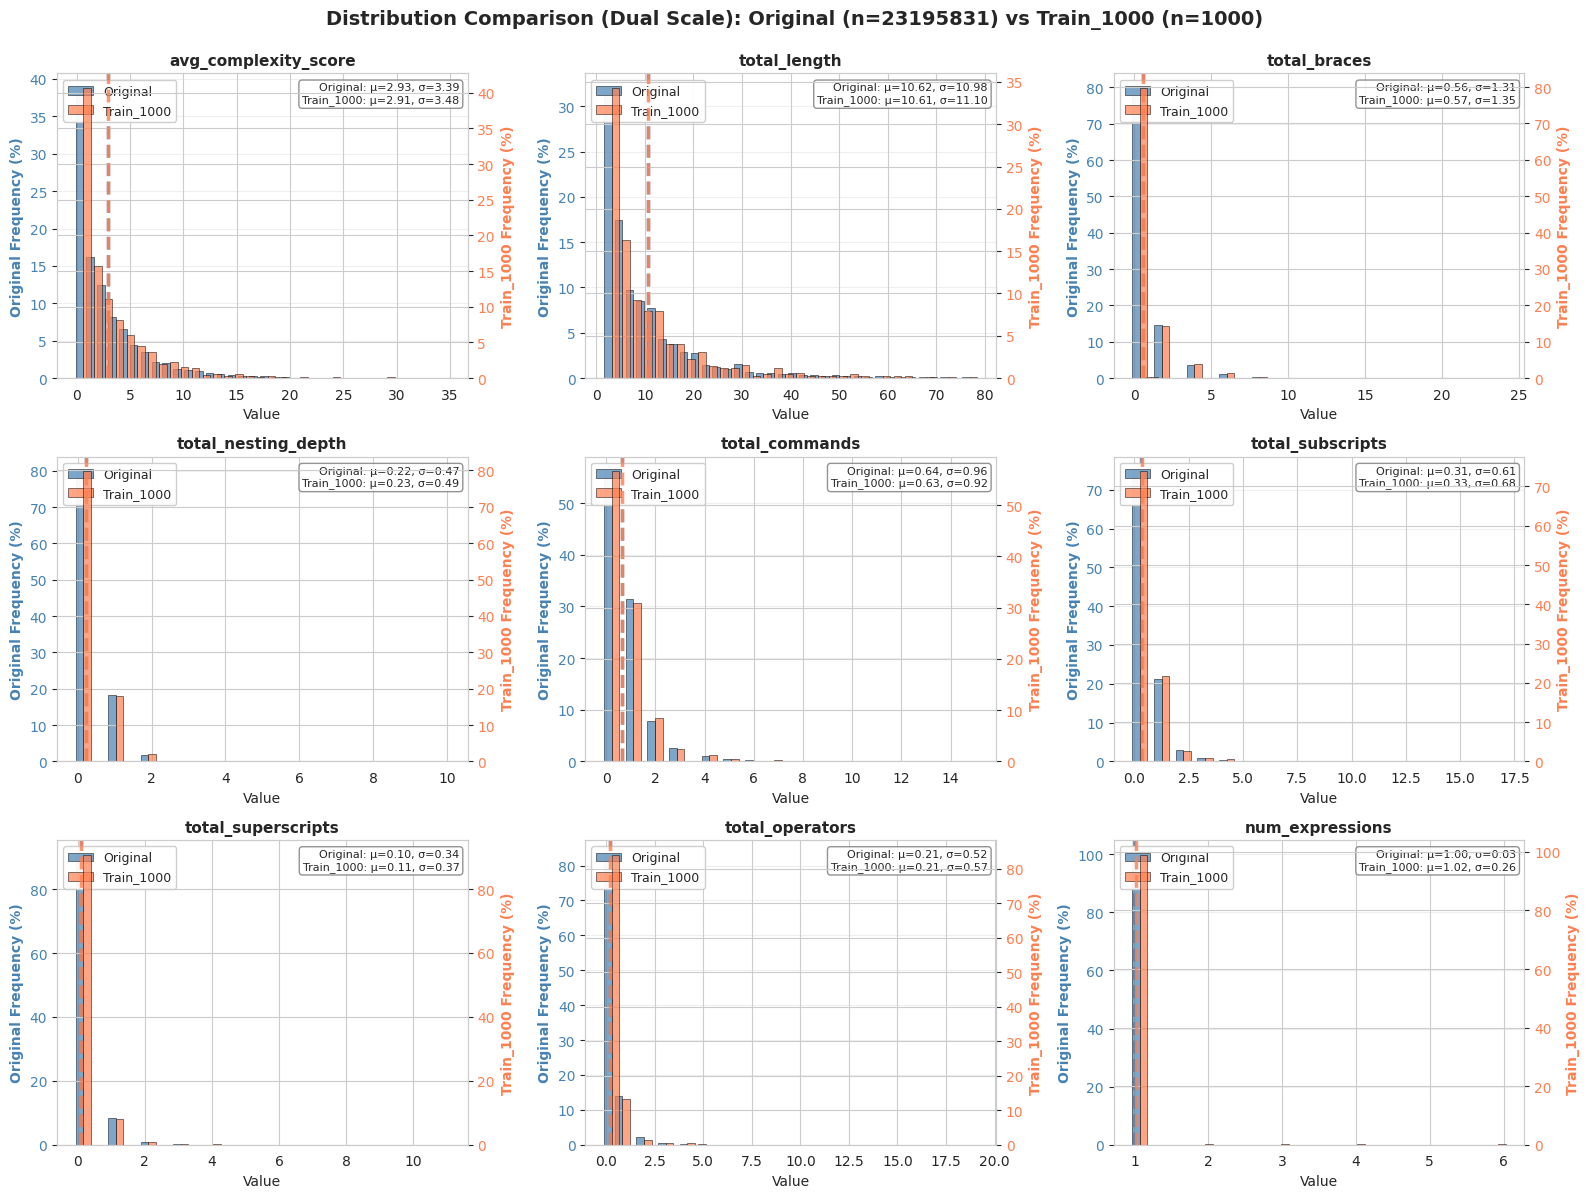


✓ Saved 'distribution_dual_scale_original_vs_train_1000.png'


COMPARING DISTRIBUTIONS: Original (n=23195831) vs Train_2000 (n=2000)

1. avg_complexity_score          
   Original: μ=  2.9282, σ=  3.3912, min=  0.1000, max= 34.7000
   Train_2000: μ=  2.9472, σ=  3.4687, min=  0.1000, max= 29.6000
   Δμ = 0.0190

2. total_length                  
   Original: μ= 10.6208, σ= 10.9751, min=  2.0000, max= 78.0000
   Train_2000: μ= 10.6550, σ= 11.0402, min=  2.0000, max= 76.0000
   Δμ = 0.0342

3. total_braces                  
   Original: μ=  0.5551, σ=  1.3065, min=  0.0000, max= 24.0000
   Train_2000: μ=  0.5625, σ=  1.3323, min=  0.0000, max= 12.0000
   Δμ = 0.0074

4. total_nesting_depth           
   Original: μ=  0.2214, σ=  0.4658, min=  0.0000, max= 10.0000
   Train_2000: μ=  0.2235, σ=  0.4834, min=  0.0000, max=  5.0000
   Δμ = 0.0021

5. total_commands                
   Original: μ=  0.6422, σ=  0.9567, min=  0.0000, max= 15.0000
   Train_2000: μ=  0.6615, σ=  0.9661, min=  0.

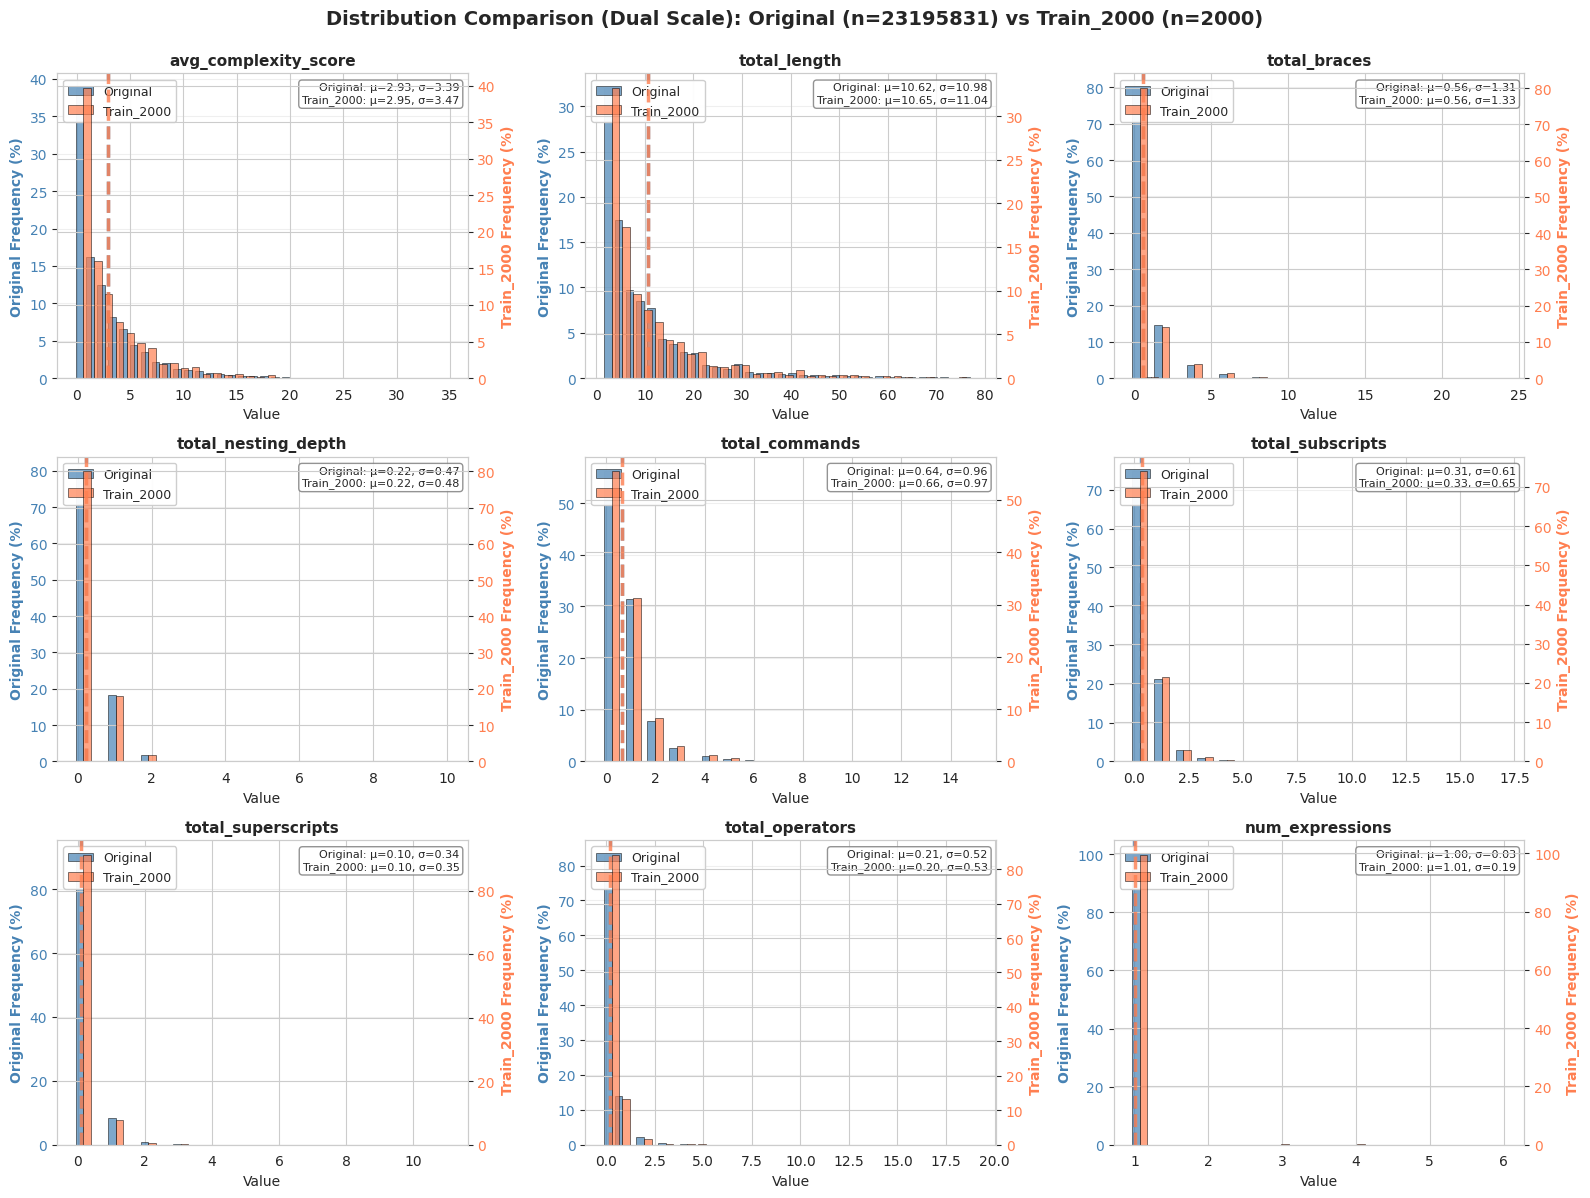


✓ Saved 'distribution_dual_scale_original_vs_train_2000.png'



In [13]:
def plot_latex_distributions_comparison_dual_scale(df_original, df_train, train_size, figsize=(16, 12)):
    """
    Plot distributions with dual y-axes (separate scales) and side-by-side bars.
    """
    
    latex_cols = [col for col in df_original.columns if col.startswith('latex_')]
    
    if not latex_cols:
        print("No LaTeX columns found!")
        return
    
    # Define the order (based on contribution list)
    col_order = [
        'latex_avg_complexity_score',
        'latex_total_length',
        'latex_total_braces',
        'latex_total_nesting_depth',
        'latex_total_commands',
        'latex_total_subscripts',
        'latex_total_superscripts',
        'latex_total_operators',
        'latex_num_expressions'
    ]
    
    # Filter to columns that exist
    col_order = [col for col in col_order if col in latex_cols]
    
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.flatten()
    
    print(f"\n{'='*100}")
    print(f"COMPARING DISTRIBUTIONS: Original (n={len(df_original)}) vs Train_{train_size} (n={len(df_train)})")
    print(f"{'='*100}\n")
    
    for idx, col in enumerate(col_order):
        ax1 = axes[idx]
        ax2 = ax1.twinx()  # Create second y-axis
        
        col_clean = col.replace('latex_', '')
        
        # Get data
        data_original = df_original[col].dropna()
        data_train = df_train[col].dropna()
        
        # Create bins based on combined data range
        min_val = min(data_original.min(), data_train.min())
        max_val = max(data_original.max(), data_train.max())
        bins = np.linspace(min_val, max_val, 35)
        
        # Calculate histogram data
        hist_original, bin_edges = np.histogram(data_original, bins=bins)
        hist_train, _ = np.histogram(data_train, bins=bins)
        
        # Normalize to percentages
        hist_original_norm = (hist_original / hist_original.sum()) * 100
        hist_train_norm = (hist_train / hist_train.sum()) * 100
        
        # Calculate bin centers for positioning
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = (bin_edges[1] - bin_edges[0]) * 0.35
        
        # Plot bars side-by-side on separate y-axes
        bars1 = ax1.bar(bin_centers - bin_width, hist_original_norm, width=bin_width*2, 
                       label='Original', color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
        bars2 = ax2.bar(bin_centers + bin_width, hist_train_norm, width=bin_width*2, 
                       label=f'Train_{train_size}', color='coral', alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Add mean lines
        mean_original = data_original.mean()
        mean_train = data_train.mean()
        ax1.axvline(mean_original, color='steelblue', linestyle='--', linewidth=2.5, alpha=0.8)
        ax2.axvline(mean_train, color='coral', linestyle='--', linewidth=2.5, alpha=0.8)
        
        # Formatting
        ax1.set_title(f'{col_clean}', fontsize=11, fontweight='bold')
        ax1.set_xlabel('Value', fontsize=10)
        ax1.set_ylabel(f'Original Frequency (%)', color='steelblue', fontweight='bold', fontsize=10)
        ax2.set_ylabel(f'Train_{train_size} Frequency (%)', color='coral', fontweight='bold', fontsize=10)
        
        ax1.tick_params(axis='y', labelcolor='steelblue')
        ax2.tick_params(axis='y', labelcolor='coral')
        
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Add statistics box
        std_original = data_original.std()
        std_train = data_train.std()
        stats_text = f'Original: μ={mean_original:.2f}, σ={std_original:.2f}\nTrain_{train_size}: μ={mean_train:.2f}, σ={std_train:.2f}'
        ax1.text(0.98, 0.97, stats_text, 
                transform=ax1.transAxes, fontsize=8, verticalalignment='top', 
                horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))
        
        # Combined legend
        ax1.legend([bars1, bars2], ['Original', f'Train_{train_size}'], 
                  loc='upper left', fontsize=9, framealpha=0.95)
        
        # Print comparison
        diff = abs(mean_original - mean_train)
        print(f"{idx+1}. {col_clean:30s}")
        print(f"   Original: μ={mean_original:8.4f}, σ={std_original:8.4f}, min={data_original.min():8.4f}, max={data_original.max():8.4f}")
        print(f"   Train_{train_size}: μ={mean_train:8.4f}, σ={std_train:8.4f}, min={data_train.min():8.4f}, max={data_train.max():8.4f}")
        print(f"   Δμ = {diff:.4f}\n")
    
    plt.suptitle(f'Distribution Comparison (Dual Scale): Original (n={len(df_original)}) vs Train_{train_size} (n={len(df_train)})', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'distribution_dual_scale_original_vs_train_{train_size}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"{'='*100}\n")
    print(f"✓ Saved 'distribution_dual_scale_original_vs_train_{train_size}.png'\n")


# Loop through each training size and compare to original
for train_size in sample_sizes:
    df_train = sample_dfs[f'train_{train_size}']
    plot_latex_distributions_comparison_dual_scale(
        df_original=df,
        df_train=df_train,
        train_size=train_size
    )